# Section 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

import joblib

pd.set_option('display.max_columns', None)

# Section 2 — Load Master Dataset

In [2]:
master = pd.read_csv("master_table.csv")

master.head()

,account_id,account_name,industry,country,plan_tier,avg_seats,avg_mrr,avg_arr,avg_tenure_days,avg_usage,avg_duration,avg_errors,total_tickets,avg_satisfaction,avg_resolution_time,churn_flag,refund_amount
0,A-00bed1,Company_306,Cybersecurity,US,Basic,34.2000,3350.6000,40207.2000,747.0000,10.005360,2748.776420,0.630360,4.0,4.0,31.750000,1,21.17
1,A-00cac8,Company_26,HealthTech,AU,Enterprise,15.3333,1569.0000,18828.0000,759.2222,10.341144,2837.913756,0.636900,2.0,NaN,33.000000,0,0.00
2,A-0158bb,Company_461,FinTech,DE,Basic,25.8333,678.3333,8140.0000,658.6667,9.638900,3190.824050,0.768517,1.0,3.0,32.000000,0,0.00
3,A-016043,Company_405,EdTech,CA,Basic,20.4545,1501.4545,18017.4545,569.1818,10.254545,2752.781818,0.386364,3.0,4.0,30.333333,1,84.75
4,A-019782,Company_142,DevTools,FR,Enterprise,13.6667,928.1111,11137.3333,802.6667,9.983767,2759.200356,0.537033,2.0,3.0,10.000000,0,0.00


# Section 3 — Dataset Overview

### Dataset Shape

In [3]:
master.shape

(500, 17)

### Dataset Information

In [4]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   account_id           500 non-null    object 
 1   account_name         500 non-null    object 
 2   industry             500 non-null    object 
 3   country              500 non-null    object 
 4   plan_tier            500 non-null    object 
 5   avg_seats            500 non-null    float64
 6   avg_mrr              500 non-null    float64
 7   avg_arr              500 non-null    float64
 8   avg_tenure_days      500 non-null    float64
 9   avg_usage            500 non-null    float64
 10  avg_duration         500 non-null    float64
 11  avg_errors           500 non-null    float64
 12  total_tickets        492 non-null    float64
 13  avg_satisfaction     466 non-null    float64
 14  avg_resolution_time  492 non-null    float64
 15  churn_flag           500 non-null    int

### Missing Values

In [5]:
master.isnull().sum()

account_id              0
account_name            0
industry                0
country                 0
plan_tier               0
avg_seats               0
avg_mrr                 0
avg_arr                 0
avg_tenure_days         0
avg_usage               0
avg_duration            0
avg_errors              0
total_tickets           8
avg_satisfaction       34
avg_resolution_time     8
churn_flag              0
refund_amount           0
dtype: int64

### Duplicate Rows

In [6]:
master.duplicated().sum()

np.int64(0)

# Section 4 — Missing Value Treatment

In [7]:
master['total_tickets'] = master['total_tickets'].fillna(0)

master['avg_satisfaction'] = (
    master['avg_satisfaction']
    .fillna(master['avg_satisfaction'].median())
)

master['avg_resolution_time'] = (
    master['avg_resolution_time']
    .fillna(master['avg_resolution_time'].median())
)

In [8]:
master.isnull().sum()

account_id             0
account_name           0
industry               0
country                0
plan_tier              0
avg_seats              0
avg_mrr                0
avg_arr                0
avg_tenure_days        0
avg_usage              0
avg_duration           0
avg_errors             0
total_tickets          0
avg_satisfaction       0
avg_resolution_time    0
churn_flag             0
refund_amount          0
dtype: int64

# Section 5 — Target Variable Analysis

### Churn Distribution

In [9]:
master['churn_flag'].value_counts()

churn_flag
1    352
0    148
Name: count, dtype: int64

In [10]:
master['churn_flag'].value_counts(normalize=True)*100

churn_flag
1    70.4
0    29.6
Name: proportion, dtype: float64

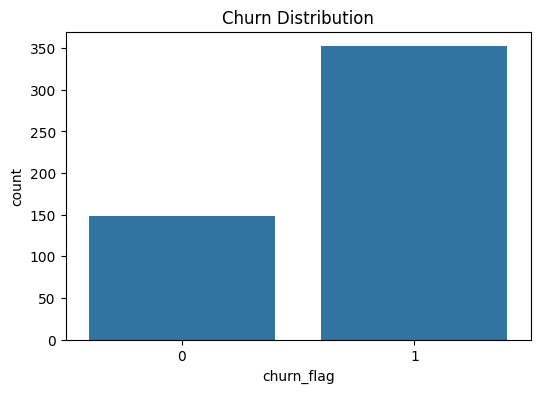

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=master,
    x='churn_flag'
)

plt.title("Churn Distribution")

plt.show()

# Section 6 — Feature Selection

### Features and Target

In [12]:
X = master.drop(
    columns=[
        'account_id',
        'account_name',
        'churn_flag',
        'refund_amount'
    ]
)

y = master['churn_flag']

In [13]:
X.columns

Index(['industry', 'country', 'plan_tier', 'avg_seats', 'avg_mrr', 'avg_arr',
       'avg_tenure_days', 'avg_usage', 'avg_duration', 'avg_errors',
       'total_tickets', 'avg_satisfaction', 'avg_resolution_time'],
      dtype='object')

# Section 7 — Encoding Categorical Variables

In [14]:
X.select_dtypes(include='object').columns

Index(['industry', 'country', 'plan_tier'], dtype='object')

In [15]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = X.select_dtypes(
    include='object'
).columns

for col in categorical_columns:

    le = LabelEncoder()

    X[col] = le.fit_transform(X[col])

    label_encoders[col] = le

In [16]:
label_encoders.keys()

dict_keys(['industry', 'country', 'plan_tier'])

In [17]:
X.head()

,industry,country,plan_tier,avg_seats,avg_mrr,avg_arr,avg_tenure_days,avg_usage,avg_duration,avg_errors,total_tickets,avg_satisfaction,avg_resolution_time
0,0,6,0,34.2000,3350.6000,40207.2000,747.0000,10.005360,2748.776420,0.630360,4.0,4.0,31.750000
1,4,0,1,15.3333,1569.0000,18828.0000,759.2222,10.341144,2837.913756,0.636900,2.0,4.0,33.000000
2,3,2,0,25.8333,678.3333,8140.0000,658.6667,9.638900,3190.824050,0.768517,1.0,3.0,32.000000
3,2,1,0,20.4545,1501.4545,18017.4545,569.1818,10.254545,2752.781818,0.386364,3.0,4.0,30.333333
4,1,3,1,13.6667,928.1111,11137.3333,802.6667,9.983767,2759.200356,0.537033,2.0,3.0,10.000000


# Section 8 — Train Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
X_train.shape

(400, 13)

In [20]:
X_test.shape

(100, 13)

# Section 9 — Feature Scaling

### Standardize Features for Logistic Regression

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Section 10 — Logistic Regression

### Train Model

In [22]:
log_model = LogisticRegression(
    max_iter=5000,
    random_state=42,
    class_weight='balanced'
)

log_model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [23]:
X.isnull().sum()

industry               0
country                0
plan_tier              0
avg_seats              0
avg_mrr                0
avg_arr                0
avg_tenure_days        0
avg_usage              0
avg_duration           0
avg_errors             0
total_tickets          0
avg_satisfaction       0
avg_resolution_time    0
dtype: int64

### Predictions

In [24]:
y_pred_log = log_model.predict(
    X_test_scaled
)

y_prob_log = log_model.predict_proba(
    X_test_scaled
)[:,1]

### Accuracy

In [25]:
accuracy_score(
    y_test,
    y_pred_log
)

0.47

### Classification Report

In [26]:
print(
    classification_report(
        y_test,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.26      0.40      0.31        30
           1       0.66      0.50      0.57        70

    accuracy                           0.47       100
   macro avg       0.46      0.45      0.44       100
weighted avg       0.54      0.47      0.49       100



### `Confusion Matrix

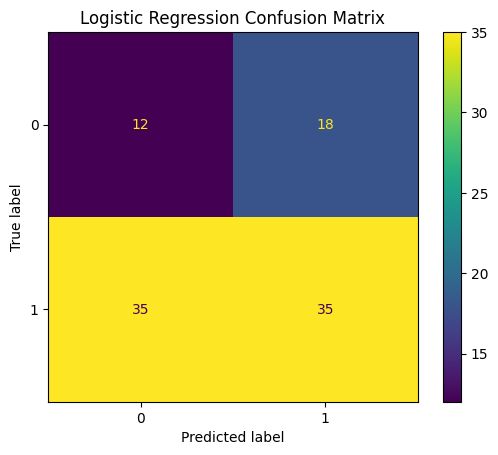

In [27]:
cm = confusion_matrix(
    y_test,
    y_pred_log
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

### ROC-AUC Score

In [28]:
roc_auc_score(
    y_test,
    y_prob_log
)

0.3766666666666667

# Section 11 — Random Forest

### Train Random Forest Model

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

### Predictions

In [30]:
y_pred_rf = rf_model.predict(
    X_test
)

y_prob_rf = rf_model.predict_proba(
    X_test
)[:,1]

### Accuracy

In [31]:
accuracy_score(
    y_test,
    y_pred_rf
)

0.67

### Classification Report

In [32]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.29      0.07      0.11        30
           1       0.70      0.93      0.80        70

    accuracy                           0.67       100
   macro avg       0.49      0.50      0.45       100
weighted avg       0.57      0.67      0.59       100



### Confusion Matrix

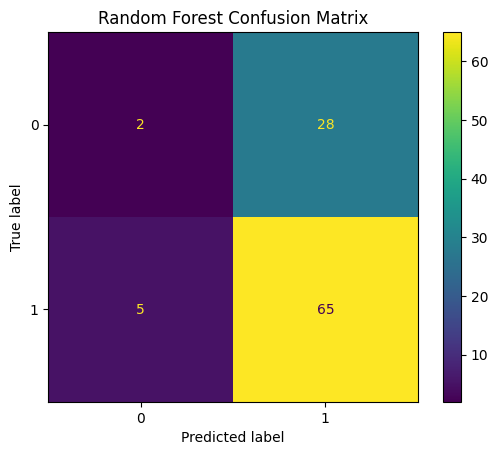

In [33]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

### ROC-AUC Score

In [34]:
roc_auc_score(
    y_test,
    y_prob_rf
)

0.508095238095238

# Section 12 — Model Comparison

### Compare Models

In [35]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(
            y_test,
            y_pred_log
        ),
        accuracy_score(
            y_test,
            y_pred_rf
        )
    ],
    "ROC_AUC": [
        roc_auc_score(
            y_test,
            y_prob_log
        ),
        roc_auc_score(
            y_test,
            y_prob_rf
        )
    ]
})

results

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.47,0.376667
1,Random Forest,0.67,0.508095


# Section 13 —Random Forest Feature Importance

### Calculate Feature Importance

In [36]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
7,avg_usage,0.110413
9,avg_errors,0.101267
5,avg_arr,0.100001
3,avg_seats,0.098689
6,avg_tenure_days,0.098582
8,avg_duration,0.095466
4,avg_mrr,0.095199
12,avg_resolution_time,0.091040
10,total_tickets,0.069812
11,avg_satisfaction,0.062562


### Visualize Top Features

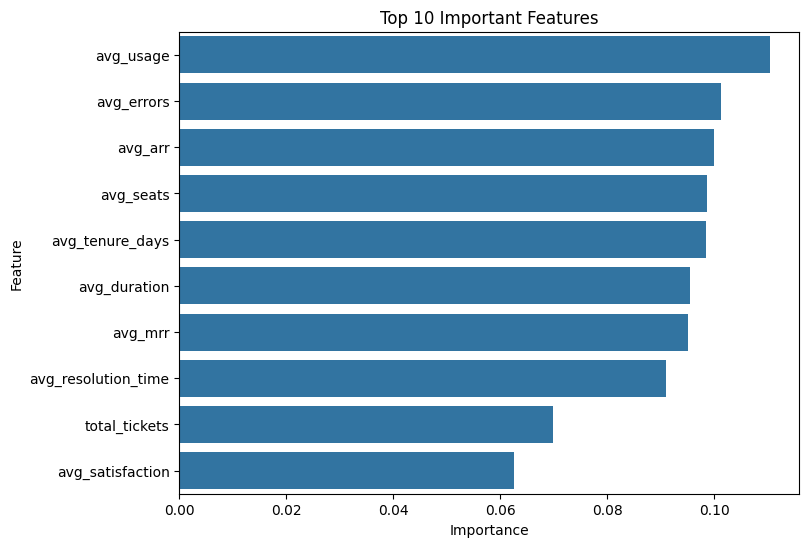

In [37]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

# Section 14 — XGBoost Model

### Create Model

In [38]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

### Train Model

In [39]:
xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

### Predictions

In [40]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

### Accuracy

In [41]:
accuracy_score(
    y_test,
    y_pred_xgb
)

0.71

### Classification Report

In [42]:
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.55      0.20      0.29        30
           1       0.73      0.93      0.82        70

    accuracy                           0.71       100
   macro avg       0.64      0.56      0.56       100
weighted avg       0.67      0.71      0.66       100



### Confusion Matrix

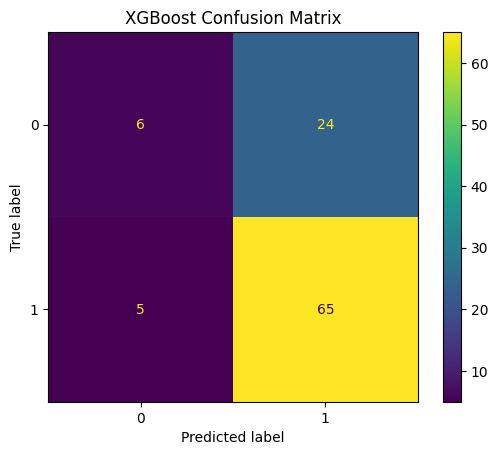

In [43]:
cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title(
    "XGBoost Confusion Matrix"
)

plt.show()

### ROC-AUC Score

In [44]:
roc_auc_score(
    y_test,
    y_prob_xgb
)

0.5566666666666666

### Update Model Comparison

In [45]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.47,0.376667
1,Random Forest,0.67,0.508095
2,XGBoost,0.71,0.556667


### Section - 15 XGBoost Feature Importance

In [46]:
importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance_xgb = importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

importance_xgb

,Feature,Importance
2,plan_tier,0.100427
10,total_tickets,0.096884
1,country,0.094197
4,avg_mrr,0.087577
11,avg_satisfaction,0.086304
3,avg_seats,0.085955
7,avg_usage,0.079758
8,avg_duration,0.078878
9,avg_errors,0.077133
12,avg_resolution_time,0.075588


### Plot

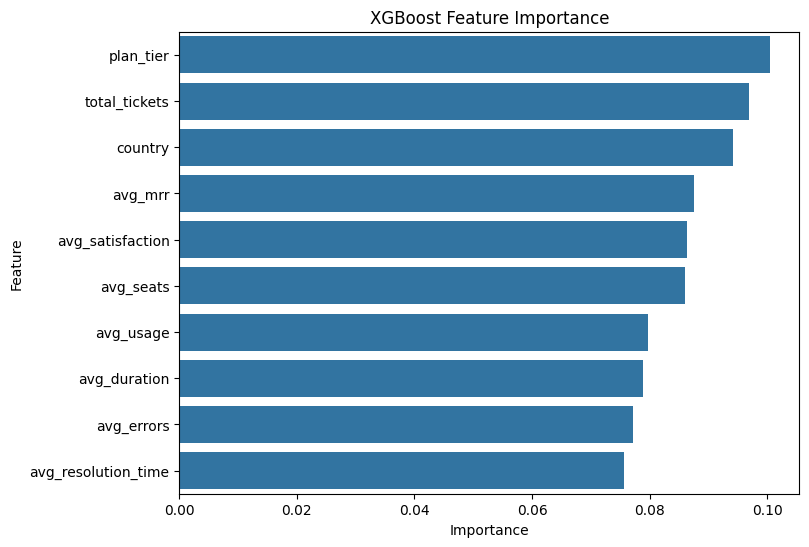

In [47]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance_xgb.head(10),
    x='Importance',
    y='Feature'
)

plt.title("XGBoost Feature Importance")

plt.show()

# Section 16 — Final Model Selection

In [48]:
results

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.47,0.376667
1,Random Forest,0.67,0.508095
2,XGBoost,0.71,0.556667


### Conclusion

XGBoost achieved the highest accuracy (71%) and ROC-AUC score (0.56).

Therefore, XGBoost was selected as the final churn prediction model for deployment and future business applications.

# Section 17 — Save Final Model

In [50]:
import joblib

# Save final XGBoost model
joblib.dump(
    xgb_model,
    "churn_model.pkl"
)

# Save label encoders
joblib.dump(
    label_encoders,
    "label_encoders.pkl"
)

# Save scaler
joblib.dump(
    scaler,
    "scaler.pkl"
)

# Save feature order
joblib.dump(
    list(X.columns),
    "feature_columns.pkl"
)

print("Files saved successfully.")
print("Model Features:", list(X.columns))

Files saved successfully.
Model Features: ['industry', 'country', 'plan_tier', 'avg_seats', 'avg_mrr', 'avg_arr', 'avg_tenure_days', 'avg_usage', 'avg_duration', 'avg_errors', 'total_tickets', 'avg_satisfaction', 'avg_resolution_time']


# Section 18 — Business Insights

Insight 1 — Product Usage Drives Retention

Customers with lower product usage and shorter session durations exhibit a higher likelihood of churn.

Insight 2 — Customer Support Impacts Churn

Customers with more support tickets and lower satisfaction scores demonstrate increased churn risk.

Insight 3 — Subscription Plans Influence Retention

Plan tier emerged as one of the strongest predictors of churn, indicating that subscription strategy affects customer retention.

Insight 4 — Customer Tenure Matters

Longer-tenure customers generally display lower churn tendencies, making tenure an important retention indicator.

Insight 5 — Revenue and Customer Value Are Important

MRR and ARR contribute significantly to churn prediction, suggesting that customer value influences customer retention.

Insight 6 — XGBoost Performed Best

Among the evaluated models, XGBoost achieved the highest predictive performance and was selected as the final churn prediction model.